# **External Ballistics and Ray Propagation**
## A Numerically Stable Trajectory Engine for Nonlinear ODE Systems

**Author:** Vanya Videva  
**Course:** Math Concepts for Developers 

**Date:** March 2026

---

### **Abstract**

External ballistics and ray propagation are two physically distinct systems that share a common mathematical structure: both can be formulated as nonlinear ordinary differential equation (ODE) problems. This project implements a unified numerical trajectory engine in Python, capable of simulating both systems through the same generic simulator and numerical integration framework.
Three numerical methods are implemented and compared: Explicit Euler, Symplectic Euler, and fourth-order Runge-Kutta (RK4). The ballistic model is studied in both a gravity-only case and a more realistic quadratic-drag case. The methods are evaluated through trajectory comparison, timestep sensitivity, and energy-based stability analysis. The results show that RK4 provides the highest accuracy in the tested simulations, while Symplectic Euler preserves the qualitative energy behavior better than Explicit Euler.
The ray propagation model demonstrates the generality of the framework: only the derivative function changes, while the simulator and numerical integrators remain the same. This shows that a common ODE-based numerical engine can be reused across different physical systems with minimal structural modification.
Future extensions of this framework could include three-dimensional trajectory simulation, wind and atmospheric models for more realistic ballistics, or application to full ray tracing in optical systems. The modular design makes it straightforward to add new physical models without changing the core engine.

## 1. Introduction

#### **What is External Ballistics?**
External ballistics is the study of a projectile's motion **after** it leaves the barrel, subject to gravity, aerodynamic drag, and atmospheric conditions **[1], [2]**. 
The mathematical foundation dates back to Newton's laws of motion **[2]**, and today it is essential in applications ranging from sport shooting to game development.

The simplest model treats the projectile as a **point mass** moving through the air, described by a system of nonlinear ordinary differential equations (ODEs) **[2], [3]**.

#### **Connection to Ray Propagation**
A ray of light traveling through a medium with a varying refractive index can follow a curved path, which may be modeled using a trajectory-based differential equation similar in structure to the ballistic case **[7]**. Both systems can therefore be treated as nonlinear ODE problems, making them suitable for demonstrating a unified numerical engine **[3], [7]**.

#### **Motivation**
The choice of numerical integrator has a significant impact on simulation accuracy. 
A poorly chosen method leads to:
- **Energy drift**, where the simulation gains or loses energy artificially **[4], [5]**
- **Numerical instability**, where small errors grow exponentially over time **[3], [4], [5]**

This project follows a similar structure to **[8]**, but focuses on numerical integration methods rather than aerodynamic modeling, and explores three integrators to demonstrate these effects.

#### **Objectives**
1. Implement a trajectory engine in **Python** using NumPy and Matplotlib
2. Model two physical systems: **ballistics with drag** and **ray in gradient medium**
3. Compare three numerical integrators: **Explicit Euler, Symplectic Euler, RK4**
4. Analyze **numerical stability** and **energy conservation** across methods
5. Visualize trajectory, energy error, and stability as a function of time step $\Delta t$



**Keywords:** External ballistics, Trajectory simulation, Numerical methods, ODE systems, Numerical stability, Ray propagation, Runge-Kutta, Symplectic Euler

## 2. Mathematical Framework

#### **What is an ODE System?**

An **Ordinary Differential Equation (ODE)** describes how a quantity changes over time. For a moving projectile, tracking two quantities:

- **Position**$(x, y)$, shows where is the projectile
- **Velocity**$(v_x, v_y)$, how fast and in which direction

The state of the system at any time $t$ is described by a vector:

$$\mathbf{s} = (x, y, v_x, v_y)$$

The ODE system describes how this state evolves over time:

$$\frac{d\mathbf{s}}{dt} = f(\mathbf{s}, t)$$

This is the standard first-order form of an ODE system **[3], [6]**.

#### **Connection to Derivatives**

Instantaneous velocity is defined as the limit of the difference quotient as $\Delta t \to 0$ **[2], [6]**:

$$v(t) = \lim_{\Delta t \to 0} \frac{s(t + \Delta t) - s(t)}{\Delta t}$$

This means velocity is the **first derivative** of position, and acceleration is the **first derivative** of velocity **[2], [6]**:

$$v_x = \frac{dx}{dt}, \quad v_y = \frac{dy}{dt}$$

$$a_x = \frac{dv_x}{dt}, \quad a_y = \frac{dv_y}{dt}$$

This gives complete ODE system:

$$\frac{dx}{dt} = v_x, \quad \frac{dy}{dt} = v_y$$

$$\frac{dv_x}{dt} = a_x, \quad \frac{dv_y}{dt} = a_y$$

Where $a_x$ and $a_y$ are accelerations caused by the forces acting on the projectile, which will be defined in the next section.

## 3. Forces Acting on the Projectile

#### **Gravity**

The simplest force acting on the projectile is gravity, a constant downward acceleration **[2]**:

$$a_x^{gravity} = 0, \quad a_y^{gravity} = -g$$

Where $g = 9.81 \, m/s^2$ is the gravitational acceleration. 
It acts only in the vertical direction and no horizontal component.

#### **Aerodynamic Drag**

In reality, the proejctile also experiences air resistance. The drag force acts opposite to the velocity direction and is proportional to the square of the speed **[1], [8]**:

$$F_{drag} = \frac{1}{2} \rho C_d A v^2$$

Where the parameters are defined in the standard aerodynamic drag formulation **[1], [8]**:
- $\rho$ is air density ($1.225 \, kg/m^3$ at sea level)
- $C_d$ is drag coefficient, depends on the projectile shape
- $A$ is cross-sectional area of the projectile
- $v = \sqrt{v_x^2 + v_y^2}$ is speed (magnitude of velocity)

This is called **quadratic drag**: the faster the projectile, the stronger the resistance.

#### **Total Acceleration**

Combining both forces using Newton's second law $F = ma$, rearranged to $a = F/m$ **[2], [8]**:

$$a_x = -\frac{F_{drag}}{m} \cdot \frac{v_x}{v}$$

$$a_y = -g - \frac{F_{drag}}{m} \cdot \frac{v_y}{v}$$

The $\frac{v_x}{v}$ and $\frac{v_y}{v}$ terms give the direction of the drag, always opposite to the direction of motion **[8]**. This completes the ODE system.




#### **Ray Propagation: A Different Kind of Force**

For a light ray traveling through a medium with varying refractive index $n(x, y)$, there is no gravity or drag, but the ray still bends. The ray curves toward regions of higher refractive index **[7]**, described by:

$$\frac{d^2\mathbf{r}}{dt^2} = \nabla n(\mathbf{r})$$

For a medium with refractive index $n(x, y) = n_0 + \alpha \cdot y$, the gradient is **[7]**:

$$\nabla n = \left(\frac{\partial n}{\partial x}, \frac{\partial n}{\partial y}\right) = (0, \alpha)$$

Substituting into the ODE system gives the state vector form $[x, y, v_x, v_y]$:

$$\frac{dx}{dt} = v_x, \quad \frac{dy}{dt} = v_y$$

$$\frac{dv_x}{dt} = \frac{\partial n}{\partial x} = 0, \qquad \frac{dv_y}{dt} = \frac{\partial n}{\partial y} = \alpha$$

This system has the same mathematical structure as the ballistic ODE system, but with different physical forces. A unified numerical engine can therefore simulate both systems with the same code.

## 4. Numerical Integration Methods

The ODE systems derived in the previous sections generally do not have simple analytical solutions once nonlinear forces such as quadratic drag are included. Instead, the trajectory must be approximated numerically by evaluating the derivatives over small time steps **[3], [4]**.

A numerical integrator advances the system state forward in time using the relation 

$$\mathbf{s}_{n+1} = \mathbf{s}_n + \Delta t$$

where $\mathbf{s}_n$ is the system state at time $t_n$ and $\Delta s$ is computed from derivatives of the system.

The choice of numerical method strongly affects simulation accuracy, stability, and energy behavior, In this project, three commonly used integrators are compared **[3], [4], [5]**:

- Explicit Euler
- Symplectic Euler
- Runge-Kutta 4 (RK4)

#### **Explicit Euler Method**

The Explicit Euler method is the simplest numerical integrator. It approximates the system’s evolution by assuming the derivative remains constant over a small time step $\Delta t$ **[3], [4]**

$$\mathbf{s}_{n+1} = \mathbf{s}_n + \Delta t\, f(\mathbf{s}_n, t_n)$$

In the projectile system this means the position and velocity are updated using the current acceleration and velocity values.
The Explicit Euler method is fast, but can be unstable for large time steps $\Delta t$ **[3], [4]**.

#### **Symplectic Euler Method**

A small but important modification of Explicit Euler method updates velocity first, then uses the **new** velocity to update position **[5]**:

$$v_{n+1} = v_n + \Delta t\, a(x_n, v_n)$$
$$x_{n+1} = x_n + \Delta t\, v_{n+1}$$

This preserves important geometric properties of the system and produces better long-term energy behavior in physical simulations **[5]**.

#### **Runge-Kutta 4 Method (RK4)**

The fourth-order Runge-Kutta method improves accuracy by evaluating the derivative at four intermediate points within each timestep **[3], [4]**:

$$k_1 = f(\mathbf{s}_n, t_n)$$
$$k_2 = f\left(\mathbf{s}_n + \frac{\Delta t}{2}k_1,\ t_n + \frac{\Delta t}{2}\right)$$
$$k_3 = f\left(\mathbf{s}_n + \frac{\Delta t}{2}k_2,\ t_n + \frac{\Delta t}{2}\right)$$
$$k_4 = f(\mathbf{s}_n + \Delta t,\ k_3,\ t_n + \Delta t)$$

$$\mathbf{s}_{n+1} = \mathbf{s}_n + \frac{\Delta t}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$

RK4 is a higher-order method and usually provides significantly better accuracy for the same timestep size **[3], [4]**.


---


**In the following implementation, these three methods will be applied to both the ballistic trajectory and the ray propagation system. Their performance will be compared in terms of:**

* **trajectory accuracy**
* **numerical stability**
* **energy conservation**
* **sensitivity to timestep $\Delta t$**
```


## 5. Implementation

This section presents the Python implementation of the numerical framework introduced earlier. The code is organized into four main parts: definition of constants and initial conditions, implementation of the physical models, implementation of the numerical integrators, and construction of a generic simulation engine. The gravity-only model is used first as a validation case before extending the system to include quadratic drag **[3], [4], [5]**.


#### 5.1 Imports and Constants

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants
G = 9.81        # gravitational acceleration (m/s^2)
RHO = 1.225     # air density at sea level (kg/m^3)

# State vector indices
X = 0
Y = 1
VX = 2
VY = 3

# Default projectile parameters
params = {
    "g": G,
    "rho": RHO,
    "cd": 0.47,
    "area": 0.01,
    "mass": 1.0
}


#### 5.2 Physical Model

This section defines the differential equations describing projectile motion **[2]**. Two physical models are implemented:
- gravity-only (used for validation)
- quadratic drag model (realistic case)

The gravity-only model follows the standard constant-acceleration projectile equations from classical mechanics [2], while the drag model uses the quadratic drag formulation introduced earlier **[1]**.

In [2]:
def only_gravity_derivatives(state, t, params=None):
    x = state[X]
    y = state[Y]
    vx = state[VX]
    vy = state[VY]

    dxdt = vx
    dydt = vy
    dvxdt = 0.0
    dvydt = -G

    return np.array([dxdt, dydt, dvxdt, dvydt], dtype=float)

def with_drag_derivatives(state, t, params):
    x = state[X]
    y = state[Y]
    vx = state[VX]
    vy = state[VY]

    g = params["g"]
    rho = params["rho"]
    cd = params["cd"]
    area = params["area"]
    mass = params["mass"]

    v = np.sqrt(vx**2 + vy**2)

    if v > 0:
        drag = 0.5 * rho * cd * area * v**2
        ax_drag = -(drag / mass) * (vx / v)
        ay_drag = -(drag / mass) * (vy / v)

    else:
        ax_drag = 0.0
        ay_drag = 0.0

    dxdt = vx
    dydt = vy
    dvxdt = ax_drag
    dvydt = -g + ay_drag

    return np.array([dxdt, dydt, dvxdt, dvydt], dtype=float)

#### Validation Tests

The following cells verify the physical model functions produce expected results.

In [3]:
# Test only_gravity_derivatives
test_state = [0.0, 0.0, 100.0, 50.0]
test_result = only_gravity_derivatives(test_state, 0)

print(f"dxdt  = {test_result[X]}")
print(f"dydt  = {test_result[Y]}")
print(f"dvxdt = {test_result[VX]}")
print(f"dvydt = {test_result[VY]}")

# Test with_drag_derivatives

test_state = [0.0, 0.0, 100.0, 50.0]
test_result = with_drag_derivatives(test_state, 0, params)

print(f"dxdt  = {test_result[X]}")
print(f"dydt  = {test_result[Y]}")
print(f"dvxdt = {test_result[VX]}")
print(f"dvydt = {test_result[VY]}")

dxdt  = 100.0
dydt  = 50.0
dvxdt = 0.0
dvydt = -9.81
dxdt  = 100.0
dydt  = 50.0
dvxdt = -32.185403451137596
dvydt = -25.902701725568797


#### 5.3 Numerical Integrators

This section implements the three numerical methods used in the project: Explicit Euler, Symplectic Euler, and fourth-order Runge-Kutta (RK4) **[3], [4], [5]**. Each integrator advances the system state by one timestep using the derivative function defined by the physical model **[3], [4]**.

In [4]:
def euler_explicit_step(f, state, t, dt, params=None):
    return state + dt * f(state, t, params)
    

def euler_symplectic_step(f, state, t, dt, params=None):
    x = state[X]
    y = state[Y]
    vx = state[VX]
    vy = state[VY]

    derivs = f(state, t, params)
    ax = derivs[VX]
    ay = derivs[VY]

    # Update velocity first:
    vx_new = vx + dt * ax
    vy_new = vy + dt * ay

    # Update position using NEW velocity:
    x_new = x + dt * vx_new
    y_new = y + dt * vy_new

    return np.array([x_new, y_new, vx_new, vy_new], dtype=float)
    

def rk4_step(f, state, t, dt, params=None):
    k1 = f(state, t, params)
    k2 = f(state + 0.5 * dt * k1, t + 0.5 * dt, params)
    k3 = f(state + 0.5 * dt * k2, t + 0.5 * dt, params)
    k4 = f(state + dt * k3, t + dt, params)

    return state + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

    

In [5]:
# Quick Test
test_state = np.array([0.0, 0.0, 100.0, 50.0])
dt = 0.1

s1 = euler_explicit_step(only_gravity_derivatives, test_state, 0, dt)
s2 = euler_symplectic_step(only_gravity_derivatives, test_state, 0, dt)
s3 = rk4_step(only_gravity_derivatives, test_state, 0, dt)

print(f"After one step (dt={dt}):")
print(f"Explicit Euler: x={s1[X]:.4f}, y={s1[Y]:.4f}, vx={s1[VX]:.4f}, vy={s1[VY]:.4f}")
print(f"Sympletic Euler: x={s2[X]:.4f}, y={s2[Y]:.4f}, vx={s2[VX]:.4f}, vy={s2[VY]:.4f}")
print(f"RK4: x={s3[X]:.4f}, y={s3[Y]:.4f}, vx={s3[VX]:.4f}, vy={s3[VY]:.4f}")

After one step (dt=0.1):
Explicit Euler: x=10.0000, y=5.0000, vx=100.0000, vy=49.0190
Sympletic Euler: x=10.0000, y=4.9019, vx=100.0000, vy=49.0190
RK4: x=10.0000, y=4.9510, vx=100.0000, vy=49.0190


#### 5.4 Generic Simulator

This section introduces a generic simulation engine responsible for advancing the system state through time. The simulator is designed to be independent of the physical model and numerical method - it receives a derivative function describing the system dynamics and an integrator for computing the next state **[3], [4]**.

This design allows the same simulator to be reused for different physical systems, such as projectile motion and ray propagation. The simulator iteratively applies the chosen integrator while recording the system state at each timestep **[3], [4]**.

The simulator takes an initial state `state0`, advances it using the chosen `integrator` and `derivative_func` for a total time `t_max` with timestep `dt`. Optional physical parameters are passed via `params`.

In [6]:
def simulate(state0, dt, t_max, integrator, derivative_func, params=None, stop_on_ground=True):
    
    state = np.array(state0, dtype=float)
    
    t = 0.0

    states = []
    times = []

    while t < t_max:
        state = integrator(derivative_func, state, t, dt, params)
        t += dt

        states.append(state.copy())
        times.append(t)

        if stop_on_ground and state[Y] < 0.0:
            break

    times = np.array(times)
    states = np.array(states)

    
    return times, states

In [7]:
# Quick Test

state0 = [0.0, 0.0, 100.0, 50.0]
dt = 0.01
t_max = 15.0

times, states = simulate(state0, dt, t_max, rk4_step, only_gravity_derivatives)

print(f"Simulation steps: {len(times)}")
print(f"Landing time: {times[-1]:.2f} s")
print(f"Landing x: {states[-1][X]:.2f} m")

Simulation steps: 1020
Landing time: 10.20 s
Landing x: 1020.00 m


#### 5.5 Ballistic Trajectory Module
This section demonstrates the simulation of projectile motion using the previously defined numerical integrators. The gravity-only model is used first as a validation case, since the exact solution can be calculated analytically. The quadratic drag model is then applied to simulate more realistic projectile trajectories **[2], [3], [8]**.

The gravity-only case is first simulated using the RK4 integrator. Since RK4 is a higher-order method with good numerical accuracy, it provides a reliable reference trajectory. This allows verification that the simulation framework behaves as expected before comparing the results with other numerical integrators **[3], [4]**.

In [8]:
# Initial condition of state and time:
state0 = [0.0, 0.0, 100.0, 50.0]
dt = 0.01
t_max = 15.0

# Run simulation:
times, states = simulate(
    state0,
    dt,
    t_max,
    rk4_step,
    only_gravity_derivatives
)

In [9]:
# Extract trajectory:
x = states[:, X]
y = states[:, Y]

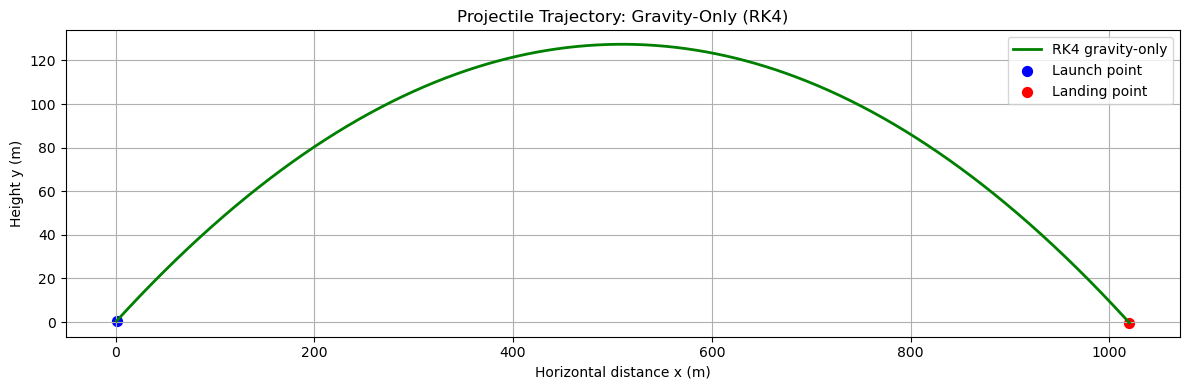

In [10]:
# Plot trajectory just for test:

plt.figure(figsize=(12, 4))

plt.plot(x, y, color="green",linewidth = 2, label="RK4 gravity-only")

plt.xlabel("Horizontal distance x (m)")
plt.ylabel("Height y (m)")

plt.title("Projectile Trajectory: Gravity-Only (RK4)")

plt.grid(True)

plt.scatter(x[0], y[0], color='blue', s=50, label="Launch point")
plt.scatter(x[-1], y[-1], color='red', s=50, label="Landing point")

plt.legend()
plt.tight_layout()
plt.show()


> **Note:** The axes are not scaled equally in this plot. The trajectory spans approximately 1020 m horizontally but only 127 m vertically. Equal scaling would compress the curve and reduce readability. A true-scale visualization is provided in Section 5.8.

- **Integrator Comparison: Gravity-Only Model**

In order to compare the behavior of the implemented numerical methods, the gravity-only projectile model is simulated using all three intergrators: Explicit Euler, Symplectic Euler, and RK4. The same initial conditions and timestep are used for each method to ensure a fair comparison **[3], [4], [5]**.

The resulting trajectories are plotted on the same graph. Since the gravity-only case has a known analytical solution, a parabolic trajectory, this experiment allows evaluation of how closely each integrator follows the expected motion and reveals the numerical differences between the methods **[2], [3], [4]**.

In [11]:
integrators = {
    "Explicit Euler": (euler_explicit_step, "red"),
    "Symplectic Euler": (euler_symplectic_step, "blue"),
    "Runge-Kutta 4": (rk4_step, "green")
}

results = {}

for name, (integrator, color) in integrators.items():
    times, states = simulate(state0, dt, t_max, integrator, only_gravity_derivatives)
    results[name] = (times, states, color)
    

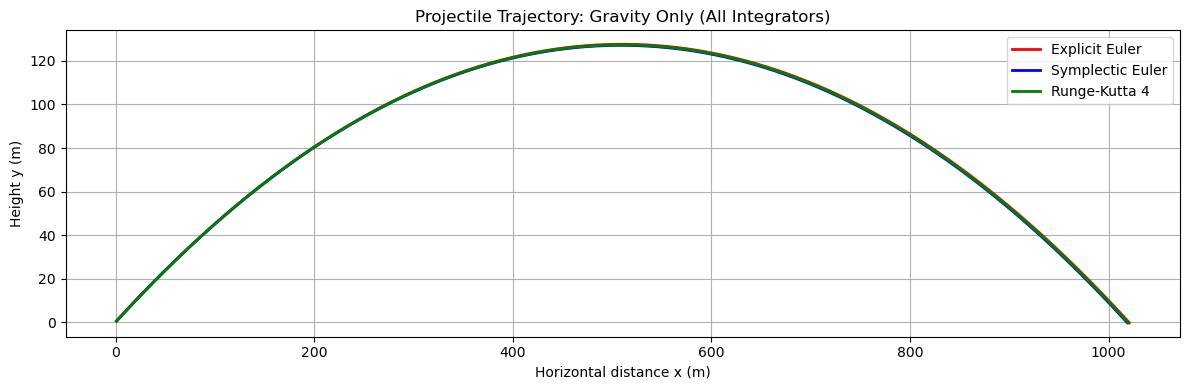

In [12]:
plt.figure(figsize=(12, 4))

for name, (times, states, color) in results.items():
    plt.plot(states[:, X], states[:, Y], color=color, linewidth=2, label=name)

plt.xlabel("Horizontal distance x (m)")
plt.ylabel("Height y (m)")
plt.title("Projectile Trajectory: Gravity Only (All Integrators)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Observation**

The trajectories produced by the three numerical integrators are almost indistinguishable for this timestep. This is expected because the timestep $\Delta t = 0.01$ s is sufficiently small, reducing the numerical error of even the lower-order methods **[3], [4]**.

However, small deviations become visible when using a larger timestep. In general, the Explicit Euler method accumulates the largest numerical error, while RK4 provides the most accurate approximation. This is demonstrated in the stability analysis in Section 5.7 **[3]. [4]. [5]**.

- **Effect of Larger Timestep**

To better illustrate the differences between the numerical integrators, the gravity-only simulation is repeated with a larger timestep $\Delta t = 0.1$ s. Increasing the timestep amplifies numerical error, making the stability and accuracy differences between Explicit Euler, Symplectic Euler, and RK4 more visible **[3], [4], [5]**.

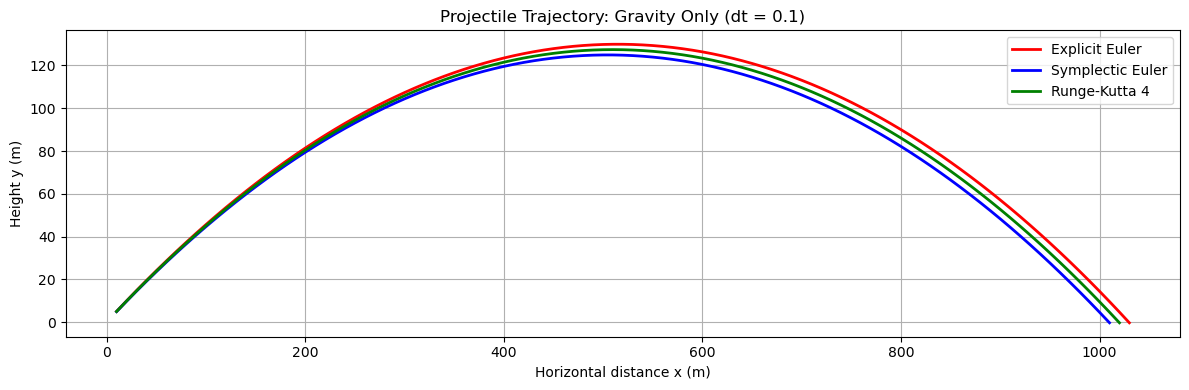

In [13]:
dt_large = 0.1

results_large_dt = {}
for name, (integrator, color) in integrators.items():
    times, states = simulate(state0, dt_large, t_max, integrator, only_gravity_derivatives)
    results_large_dt[name] = (times, states, color)

plt.figure(figsize=(12, 4))

for name, (times, states, color) in results_large_dt.items():
    plt.plot(states[:, X], states[:, Y], color=color, linewidth=2, label=name)

plt.xlabel("Horizontal distance x (m)")
plt.ylabel("Height y (m)")
plt.title(f"Projectile Trajectory: Gravity Only (dt = {dt_large})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Observation**

With $\Delta t = 0.1$ s, the differences between the integrators become clearly visible. The Explicit Euler method overshoots the expected trajectory, landing further than the analytical solution predicts - a sign of energy accumulation. RK4 remains closest to the true parabolic trajectory, while Symplectic Euler falls between the two **[2], [3], [4]**.

- **Integrator Comparison: Quadratic Drag Model**

The simulation is repeated with the quadratic drag model to produce a more realistic projectile trajectory. Air resistance reduces both the range and maximum height compared to the gravity-only case **[1], [8]**.

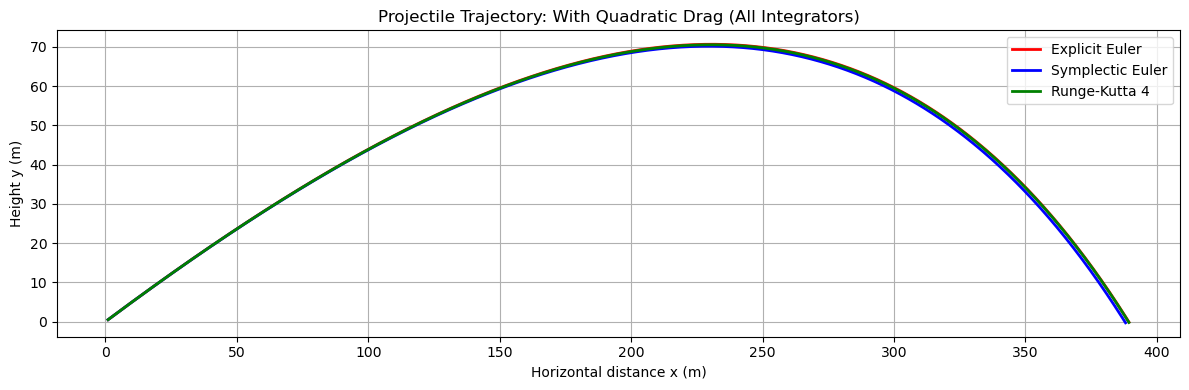

In [14]:
results_drag = {}
for name, (integrator, color) in integrators.items():
    times, states = simulate(state0, dt, t_max, integrator, with_drag_derivatives, params)
    results_drag[name] = (times, states, color)

plt.figure(figsize=(12, 4))

for name, (times, states, color) in results_drag.items():
    plt.plot(states[:, X], states[:, Y], color=color, linewidth=2, label=name)

plt.xlabel("Horizontal distance x (m)")
plt.ylabel("Height y (m)")
plt.title("Projectile Trajectory: With Quadratic Drag (All Integrators)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Observation**

When quadratic drag is included, the projectile reaches a significantly lower maximum height and a much shorter horizontal range compared to the gravity-only case. The trajectory is also no longer symmetric, since the drag force depends on the projectile velocity and continuously removes energy from the system **[1], [8]**.

The three numerical integrators produce nearly identical trajectories for the chosen timestep $\Delta t = 0.01$ s. As demonstrated in the gravity-only case, larger timesteps would reveal differences between the methods, with Explicit Euler accumulating the largest error and RK4 remaining the most accurate **[3], [4], [5]**.

#### 5.6 Ray Propagation Module

To demonstrate that the numerical framework is not limited to projectile motion, it is also applied to a simplified ray propagation problem. In a non-uniform medium, a light ray can bend due to spatial changes in the refractive index **[7]**. This allows the ray trajectory to be described using a differential equation similar in structure to the ballistic case.

The goal of this section is not to implement a full ray tracer, but rather to show that the same numerical integrators and generic simulator can be reused for another trajectory-based system.

The following derivative function implements a simplified ray propagation model consistent with the trajectory-based ODE framework introduced earlier.

In [15]:
def ray_derivatives(state, t, params):
    x = state[X]
    y = state[Y]
    vx = state[VX]
    vy = state[VY]

    alpha = params["alpha"]

    dxdt = vx
    dydt = vy
    dvxdt = 0.0        # dn/dx = 0 for linear y-gradient
    dvydt = alpha      # dn/dy = alpha

    return np.array([dxdt, dydt, dvxdt, dvydt], dtype=float)

In [16]:
# Ray propagation parameters
ray_params = {"alpha": 0.03}

# Initial conditions: ray starts at origin, traveling horizontally
ray_state0 = [0.0, 0.0, 3.0, 0.0]
ray_dt = 0.01
ray_t_max = 20.0

The **simulation** is run using the RK4 integrator as a reference trajectory, with `stop_on_ground=False` since the ray does not terminate at ground level.

In [17]:
# Run simulation
ray_times, ray_states = simulate(ray_state0, ray_dt, ray_t_max, rk4_step, ray_derivatives, params = ray_params, stop_on_ground = False)

# Extract trajectory
ray_x = ray_states[:, X]
ray_y = ray_states[:, Y]

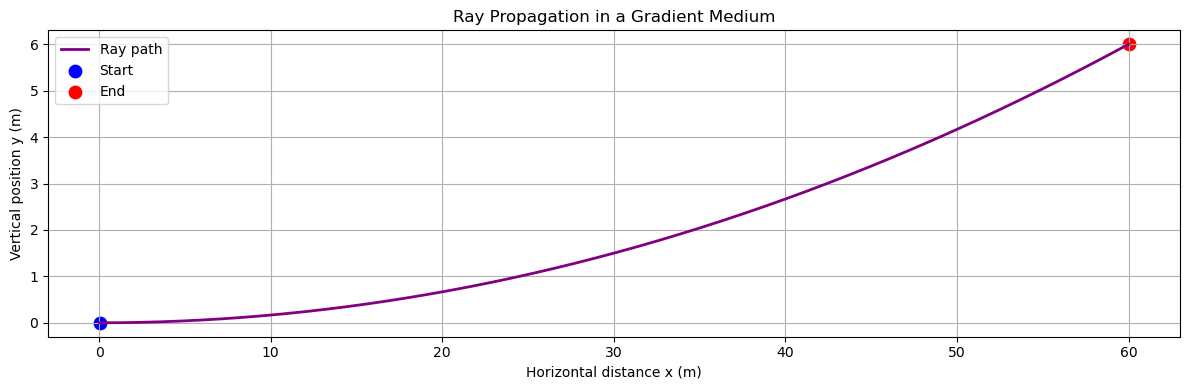

In [18]:
# Plot
plt.figure(figsize=(12, 4))

plt.plot(ray_x, ray_y, color="purple", linewidth=2, label="Ray path")

plt.scatter(ray_x[0], ray_y[0], color="blue", s=80, label="Start")
plt.scatter(ray_x[-1], ray_y[-1], color="red", s=80, label="End")

plt.xlabel("Horizontal distance x (m)")
plt.ylabel("Vertical position y (m)")
plt.title("Ray Propagation in a Gradient Medium")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Observation**

The simulated ray follows a curved trajectory due to the imposed refractive-index gradient. Although the model is simplified, it demonstrates that the same numerical framework used for projectile motion can also be applied to ray propagation. Only the derivative function changes, while the numerical integrators and the generic simulator remain the same.

#### 5.7 Stability and Numerical Error Analysis

Numerical integration methods approximate the continuous equations of motion using discrete timesteps. The accuracy and stability of the simulation therefore depend on both the chosen integration method and the timestep $\Delta t$ **[3], [4], [5]**.

In the previous sections, projectile trajectories were simulated using Explicit Euler, Symplectic Euler, and RK4. While the results appear similar for small timesteps, numerical differences become more pronounced as the timestep increases.

This section briefly examines the numerical stability of the implemented methods by analyzing their behavior with respect to timestep size and energy conservation.

- **Effect of Timestep Size**

The timestep $\Delta t$ controls the resolution of the numerical integration. Smaller timesteps generally produce more accurate results but require more computational steps. Larger timesteps reduce computation time but may introduce significant numerical errors **[3], [4]**.

As demonstrated in the gravity-only simulations, the trajectories produced by the different integrators are nearly identical when a small timestep ($\Delta t = 0.01$) is used. However, increasing the timestep ($\Delta t = 0.1$) amplifies numerical differences.

The Explicit Euler method exhibits the largest deviation from the expected trajectory, while the RK4 method remains the most accurate due to its higher-order formulation. The Symplectic Euler method provides intermediate accuracy and preserves the qualitative behavior of the system better than Explicit Euler **[5]**.

- **Energy behavior of different integrators**

For gravity-only motion, the total mechanical energy should remain constant **[2], [5]**:

$$E = \frac{1}{2}m(v_x^2 + v_y^2) + mgy$$

Where $\frac{1}{2}m(v_x^2 + v_y^2)$ is kinetic energy and $mgy$ is potential energy.

In [19]:
def calculate_energy(states, params):
    
    m = params["mass"]
    g = params["g"]

    vx = states[:, VX]
    vy = states[:, VY]
    y = states[:, Y]

    kinetic = 0.5 * m * (vx**2 + vy**2)
    potential = m * g * y
    
    return kinetic + potential

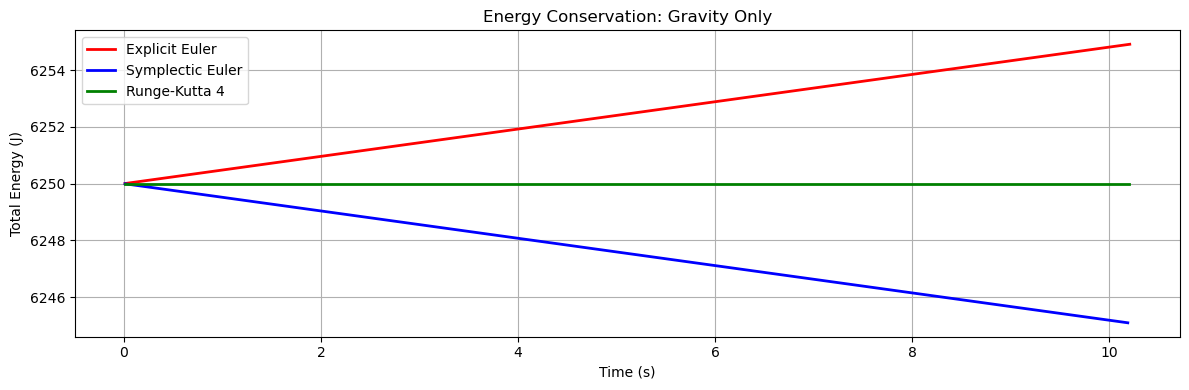

In [20]:
plt.figure(figsize=(12, 4))

for name, (times, states, color) in results.items():
    energy = calculate_energy(states, params)
    plt.plot(times, energy, color=color, linewidth=2, label=name)

plt.xlabel("Time (s)")
plt.ylabel("Total Energy (J)")
plt.title("Energy Conservation: Gravity Only")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Observation**

For ideal projectile motion without drag, the total mechanical energy should remain constant. The energy plot shows that the RK4 integrator preserves energy very accurately over the duration of the simulation. In contrast, the Explicit Euler method introduces numerical energy growth, while the Symplectic Euler method produces a small energy decrease over time. These results illustrate the different stability properties of the numerical integrators **[2], [4], [5]** and confirm that RK4 is the most suitable method for long-term simulations.

- **Relative Energy Error**

To quantify the numerical drift of the total mechanical energy, the relative energy error is computed. For an ideal projectile without drag, the total energy should remain constant. Any deviation from the initial value is therefore caused by numerical integration error **[2], [4], [5]**.

The relative error is defined as:

$$\epsilon = \frac{E(t) - E_0}{E_0}$$

where $E_0$ is the initial energy and $E(t)$ is the energy at time $t$.

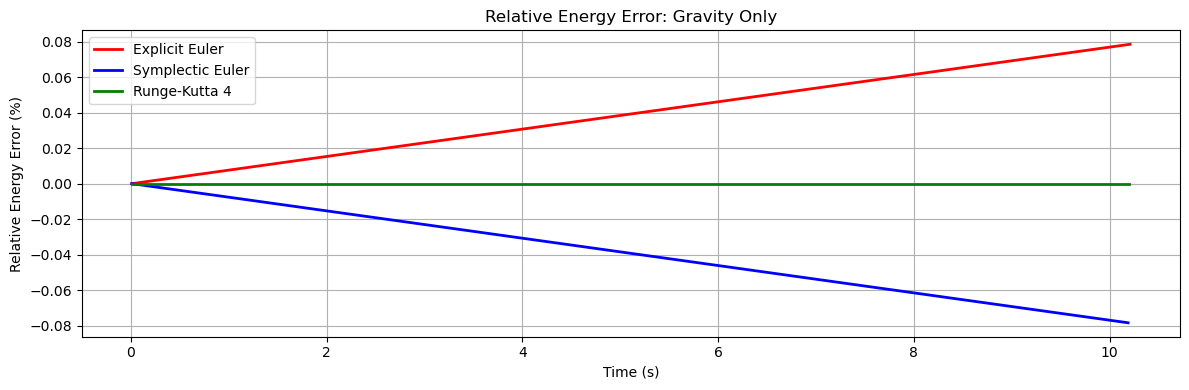

In [21]:
plt.figure(figsize=(12, 4))
for name, (times, states, color) in results.items():
    energy = calculate_energy(states, params)
    E0 = energy[0]
    relative_energy_error = (energy - E0) / E0 * 100
    plt.plot(times, relative_energy_error, color=color, linewidth=2, label=name)

plt.xlabel("Time (s)")
plt.ylabel("Relative Energy Error (%)")
plt.title("Relative Energy Error: Gravity Only")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Observation**

For ideal projectile motion without drag, the total mechanical energy should remain constant. The relative energy error plot shows that the RK4 integrator preserves energy very accurately, with almost no numerical drift. In contrast, the Explicit Euler method introduces a gradual increase in energy, while the Symplectic Euler method produces a small decrease. These results illustrate the different stability properties of the numerical integrators and show that RK4 provides the most accurate energy behavior among the tested methods for this simulation setup.

---
**Extension to ray propagation**

Although the numerical error analysis in this section focuses on projectile motion, the same considerations apply to the ray propagation model. Since the ray path is also obtained through numerical integration of a trajectory-based ODE system, the choice of timestep and integrator affects the smoothness and accuracy of the resulting curve in the same way.

#### 5.8 Visualization

The previous trajectory figures were scaled primarily for readability. However, this can visually distort the geometric proportions of the simulated motion. 
In this section, true-scale plots are shown for both the ballistic trajectory and the ray propagation model by enforcing equal scaling on the horizontal and vertical axes. These figures provide a more physically faithful representation of the simulated paths and highlight the difference in geometric scale between the two systems.

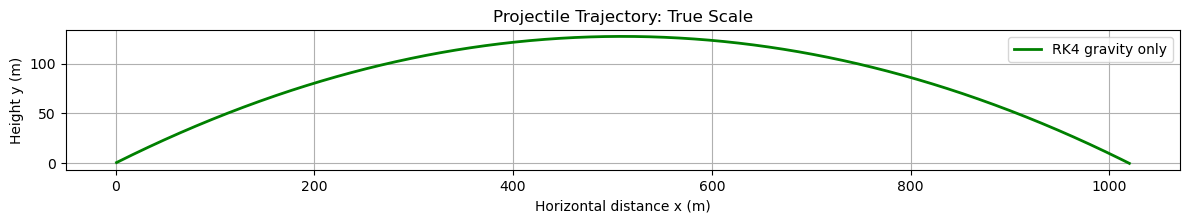

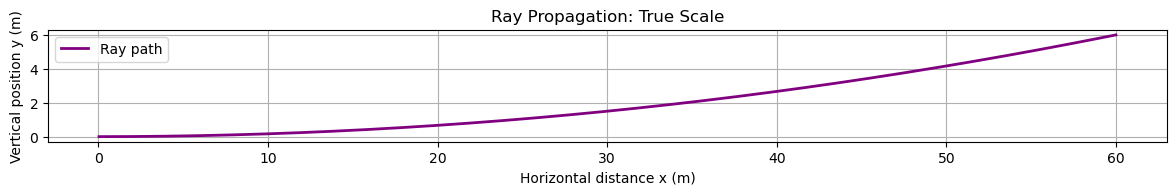

In [22]:
rk4_states = results["Runge-Kutta 4"][1]
x_true = rk4_states[:, X]
y_true = rk4_states[:, Y]

# Ballistic trajectory (true scale)
plt.figure(figsize=(12, 4)) 
plt.plot(x_true, y_true, color="green", linewidth=2, label="RK4 gravity only")

plt.xlabel("Horizontal distance x (m)")
plt.ylabel("Height y (m)")
plt.title("Projectile Trajectory: True Scale")
plt.legend()
plt.grid(True)

plt.gca().set_aspect("equal")
plt.tight_layout()
plt.show()

# Ray propagation - true scale
plt.figure(figsize=(12, 4))
plt.plot(ray_x, ray_y, color="purple", linewidth=2, label="Ray path")

plt.xlabel("Horizontal distance x (m)")
plt.ylabel("Vertical position y (m)")
plt.title("Ray Propagation: True Scale")
plt.legend()
plt.grid(True)

plt.gca().set_aspect("equal")
plt.tight_layout()
plt.show()

**Observation**

When plotted with equal axis scaling, the ballistic trajectory appears much flatter than in the earlier readability-oriented figures. This reflects the true geometric proportions of the motion, since the projectile travels much farther horizontally than it rises vertically. In contrast, the ray trajectory occupies a more balanced geometric scale within the simulated domain. These true-scale visualizations complement the earlier plots by showing the actual spatial proportions of both systems.

### Acknowledgements

This project was developed with the assistance of Claude (Anthropic).

## References

**[1]** McCoy, R. L. *Modern Exterior Ballistics*. Schiffer Publishing, 1999.

**[2]** Taylor, J. R. *Classical Mechanics*. University Science Books, 2005.

**[3]** Hairer, E., Nørsett, S. P., Wanner, G. *Solving Ordinary Differential Equations I*. Springer, 1993.

**[4]** Burden, R. L., Faires, J. D. *Numerical Analysis*. Cengage Learning, 2010.

**[5]** Hairer, E., Lubich, C., Wanner, G. *Geometric Numerical Integration*. Springer, 2006.

**[6]** Darakchiev, Y. *Math Concepts for Developers*. SoftUni, 2026.

**[7]** Born, M., Wolf, E. *Principles of Optics* (7th ed.). Cambridge University Press, 1999.

**[8]** Cucchi, L. *External Ballistics: Flight Dynamics Simulation and Projectile Aerodynamics*. Master's Thesis, Politecnico di Milano, 2023-24.

---
$$ \text{Ballistics and Ray Propagation}$$
$$\blacksquare $$
